# Atmospheric energy and water balance — Full-CPL spin-up + piControl

Figures:
* `Full-CPL_atm_trend_summary_global.pdf`
* `Full-CPL_atm_trend_summary_hemisphere.pdf`

**Setup** holds everything you normally change: paths, the experiment table, labels, colors and years. Each analysis step then has a **settings** cell (its parameters and plot style) and a **compute & plot** cell that calls the shared classes in `../util/` directly. Figures are saved to `FIG_DIR` (public_html) and cached/derived data to `DATA_DIR` (public_html `data/`, indexed in `data/README.md`).

In [1]:
import os, sys
WF_ROOT = os.path.abspath("..")            # coupled_spinup_eval/
if WF_ROOT not in sys.path:
    sys.path.insert(0, WF_ROOT)
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")
%matplotlib inline

import os
import glob
import string
import numpy as np
import xarray as xr
import cftime
import warnings

from scipy.stats import linregress
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter, FixedLocator

from util.ctrl_plotting import AtmosphereBalancePlotter
from util.ctrl_processing import AtmosphereBalanceAnalysis
from util.experiments import build_exp_subdirs_from_run_dict, make_run_dict
from util.figures import publish

## Setup

In [2]:
# ---- paths ----
MODEL_ROOT   = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/E3SMv3_testings"     # case directories
OUTPUT_ROOT  = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper"   # published figures/ and data/
OUTPUT_URL   = "https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper"
FIG_DIR      = f"{OUTPUT_ROOT}/figures/atm_flux"
DATA_DIR     = f"{OUTPUT_ROOT}/data/atm_flux"              # cached/derived data (index: data/README.md)
OBS_DIR      = f"{OUTPUT_ROOT}/data/obs"                                          # HadSST Nino3.4 reference

# ---- experiments: case directory names (under MODEL_ROOT) and model-year periods ----
EXPERIMENTS = {
    "Full-CPL": {
        "spin-up":   {"name": "20231209.v3.LR.piControl-spinup.chrysalis",      "period": "0001-2000"},
        "piControl": {"name": "v3.LR.piControl",                                "period": "0001-0500"},
    },
    "AltBG1": {
        "spin-up":   {"name": "20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0001-0220"},
        "piControl": {"name": "20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0221-0350"},
    },
    "AltBG2": {
        "spin-up":   {"name": "20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0001-0220"},
        "piControl": {"name": "20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0221-0350"},
    },
    "AltBG3": {
        "spin-up":   {"name": "20241105.v3.LR.piControl.Rerun.BC2GC.anvil",     "period": "0001-2000"},
        "piControl": {"name": "20241105.v3.LR.piControl.Rerun.BC2GC.anvil",     "period": "0001-0500"},
    },
}
LABEL = {"Full-CPL": "FC", "AltBG1": "FC-FOSI-S1", "AltBG2": "FC-FOSI-S2", "AltBG3": "FC-FOSI-S3"}

# ---- analysis settings ----
EXPERIMENT     = "Full-CPL"    # experiment analysed (spin-up followed by its piControl)
CTRL_YEARS     = (0, 2500)     # combined spin-up + piControl model years (axes, cache/figure names)
SPINUP_MARKERS = (350, 2000)   # vertical markers; trends fit from the first, decay fit up to the second


In [3]:
# Shared inputs/outputs
run_dict = make_run_dict(EXPERIMENTS, MODEL_ROOT)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
publish(OUTPUT_ROOT, FIG_DIR)
print("figures ->", FIG_DIR)
print("data    ->", DATA_DIR)
print("web     ->", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))

figures -> /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/atm_flux
web     -> https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/atm_flux


## 1 Energy and water balance time series

In [4]:
data_dir    = MODEL_ROOT
out_dir     = DATA_DIR
os.makedirs(out_dir, exist_ok=True)

# === Select experiment ===
experiments = [EXPERIMENT] 
component = "atm"
subdir = f"post/time_series/{component}"

if 'run_dict' not in globals():
    raise RuntimeError("[ERROR] 'run_dict' is not defined. Please define it before running.")

region_map = {
     0: "Global", 
     1: "Northern Hemisphere", 
     2: "Southern Hemisphere"
}

var_dict = {
    "net_toa_flux_restom":             {"name": "RESTOM",   'label': "RESTOM",  'unit': 'W m$^{-2}$'},
    "net_sfc_flux_ressurf":            {"name": "RESSURF",  'label': "RESSURF", 'unit': 'W m$^{-2}$'},
    "global_surface_skin_temperature": {"name": "TS",       'label': "TS",      'unit': '$^{o}$C'},
    "global_surface_air_temperature":  {"name": "TAS",      'label': "TAS",     'unit': '$^{o}$C'},
    "toa_radiation":                   {"name": "RESTOA",   'label': "RESTOA",  'unit': 'W m$^{-2}$'},
    "net_atm_energy_imbalance":        {"name": "RESNET",   'label': "RESNET",  'unit': 'W m$^{-2}$'},
    "net_atm_water_imbalance":         {"name": "MASSFLUX", 'label': "E - P",   'unit': 'mm yr$^{-1}$'},
}

annual = True
force_process = True # False if file already processed
xr_engine = "netcdf4"
xr_chunks = None 

for exp in experiments:

    if exp not in run_dict:
        raise ValueError(f"[ERROR] '{exp}' not found in run_dict.")

    spinup_name    = run_dict[exp]["spin-up"]["name"]
    picontrol_name = run_dict[exp]["piControl"]["name"]

    # === Initialize analysis ===
    reader = AtmosphereBalanceAnalysis(
        base_dir=data_dir,
        spinup_name=spinup_name,
        picontrol_name=picontrol_name,
        component=component,
        subdir=subdir,
        region_map=region_map,
        var_dict=var_dict,
        xr_engine=xr_engine,
        xr_chunks=xr_chunks
    )

    # === Compute and save dataset ===
    suffix = "annual" if annual else "monthly"
    output_file = os.path.join(out_dir, f"{exp}_energy_timeseries_{suffix}.nc")

    print(f"[INFO] Starting energy flux processing for: {exp}")

    reader.to_timeseries_df(
        exp, 
        output_file, 
        annual=annual, 
        force_process=force_process
    )

publish(FIG_DIR, DATA_DIR)
print("web:", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))


[INFO] Starting energy flux processing for: Full-CPL


/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/coupled_spinup_evaluation/util/ctrl_processing.py:3295: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  with xr.open_mfdataset(
/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/coupled_spinup_evaluation/util/ctrl_processing.py:3295: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  with xr.open_mfdataset(
/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/coupled_spinup_evaluation/util/ctrl_processing.py:3295: SerializationWarning: Unable to decode time axis into ful

web: https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/atm_flux


## 2.1 Trend summary, global
### Settings

In [5]:
data_dir    = MODEL_ROOT
data_dir    = DATA_DIR
fig_dir     = FIG_DIR #os.path.join(results_dir, "figures")
os.makedirs(fig_dir, exist_ok=True)

# === Select experiment ===
experiment = EXPERIMENT
season = "annual" # or monthly
spinup_period = list(SPINUP_MARKERS)
plot_syear = CTRL_YEARS[0]
plot_eyear = CTRL_YEARS[1]

if 'run_dict' not in globals():
    raise RuntimeError("[ERROR] 'run_dict' is not defined. Please define it before running.")

if experiment not in run_dict:
    raise ValueError(f"[ERROR] '{experiment}' not found in run_dict.")

combined_tidy = os.path.join(
    data_dir, f"{experiment}_energy_timeseries_{season}.nc"
)

if not os.path.isfile(combined_tidy):
    raise FileNotFoundError(f"Missing tidy file: {combined_tidy}")

# === Region labels ===
region_labels = {
    0: "Global",
    1: "Northern Hemisphere",
    2: "Southern Hemisphere"
}

# === Plot variables ===
var_dict = {
    #"global_surface_skin_temperature": {
    #    "name": "TS",       'label': "TS",      'unit': '$^{o}$C'
    #},
    #"net_toa_flux_restom":            {
    #    "name": "RESTOM",   'label': "RESTOM",  'unit': r'W m$^{-2}$'
    #},
    "TAS": {
        "name": "TAS", 
        'label': "Surface Air Temperature",  
        'unit': r'$^{o}$C',
        "decay" : True,
        "min"   : 12.0,
        "max"   : 15.0,
        "dmin"  : -0.8,
        "dmax"  : 0.8,
    },
    "RESSURF": {
        "name": "RESSURF", 
        'label': "Residual at Surface",  
        'unit': r'W m$^{-2}$',
        "decay" : False,
        "min"   : -3.5,
        "max"   : 3.5,
        "dmin"  : -2.0,
        "dmax"  : 2.0,
    },
    "RESTOA": {
        "name": "RESTOA",   
        'label': "Residual at Top of Atmosphere",  
        'unit': r'W m$^{-2}$',
        "decay" : False,
        "min"   : -3.5,
        "max"   : 3.5,
        "dmin"  : -2.0,
        "dmax"  :  2.0,
    },
    "RESNET": {
        "name": "RESNET",   
        'label': "Net Energy Flux",  
        'unit': r'W m$^{-2}$',
        "decay" : False,
        "min"   : -1.5,
        "max"   : 1.5,
        "dmin"  : -0.4,
        "dmax"  :  0.4,
    },
    "MASSFLUX": {
        "name": "MASSFLUX", 
        'label': "Net Mass Flux (E - P)",   
        'unit': r'mm yr$^{-1}$',
        "decay" : False,
        "min"   : -160.0,
        "max"   :  160.0,
        "dmin"  : -1.5,
        "dmax"  :  1.5,
    },
}
show_mean_box = False 
vars_for_mean_box = [
    "RESSURF",
    "RESTOA",
    "RESNET",
    "MASSFLUX",
]
window = 10
box_window = 50
filter_window = 11
init_window = 0
nxlab = 250
force_process = False # Flase if file already processed
xr_engine = "netcdf4"
xr_chunks = None 

show_decay = True 
show_filter = True 
decay_fit_range=(plot_syear, spinup_period[1])     # e.g., (0, 350) or (0, spinup_markers[0])
decay_tail_years=200

use_filtered_for_fit=True
figsize = (40,48)
fontz = 30
nrows = 1
ncols = 2
fig_id = 0

# Create default positions for all short names
show_trend_range_box = True 
trend_mode = "full_period"
trend_fit_range = (spinup_period[0],plot_eyear)        # e.g., (syear, eyear) or (spinup_markers[0], eyear)
use_filtered_for_trend = True  # use yf if available

text_position_dict = {
    meta['name']: {'x': 0.02, 'y': 0.98}
    for meta in var_dict.values()
}
# Override specific variables with custom positions
text_position_dict.update({
    'TAS':      {'x': 0.50, 'y': 0.10},
    'RESSURF':  {'x': 0.50, 'y': 0.10},
    'RESTOA':   {'x': 0.50, 'y': 0.10},
    'RESNET':   {'x': 0.50, 'y': 0.10},
    'MASSFLUX': {'x': 0.50, 'y': 0.10}
}) 

# === Summary grid ===
varnames   = [meta["name"] for meta in var_dict.values()]
plot_dict = {
    meta["name"]: {
        "label": meta["label"],
        "unit": meta["unit"],
        "decay": meta.get("decay", False),
        "min": meta.get("min", None),
        "max": meta.get("max", None),
        "dmin": meta.get("dmin", None),
        "dmax": meta.get("dmax", None),
        "decay": meta.get("decay", False),
    }
    for meta in var_dict.values()
}

color_dict = {
    'black': '#000000', 'blue': '#1f77b4', 'red': '#d62728',
    'skyblue': '#87ceeb', 'gray': '#7f7f7f'
}


### Compute & plot

/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/coupled_spinup_evaluation/util/ctrl_plotting.py:1053: UserWarning: Unit missing for 'RESSURF' [region=Global]. Expected 'None'. Data will be used as-is; set df.attrs['units']['RESSURF'] to silence.
  self._check_and_warn_units(varname, units_map, y=y, where=f"region={name}")
/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/coupled_spinup_evaluation/util/ctrl_plotting.py:1053: UserWarning: Unit missing for 'RESSURF' [region=Northern Hemisphere]. Expected 'None'. Data will be used as-is; set df.attrs['units']['RESSURF'] to silence.
  self._check_and_warn_units(varname, units_map, y=y, where=f"region={name}")
/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/coupled_spinup_evaluation/util/ctrl_plotting.py:1053: UserWarning: Unit missing for 'RESSURF' [region=Southern Hemisphere]. Expected 'None'. Data will be used as-is; set df.attrs['units']['RESSURF'] to silence.
  self._check_and

[PLOT] Saved: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/atm_flux/Full-CPL_atm_trend_summary_global.pdf


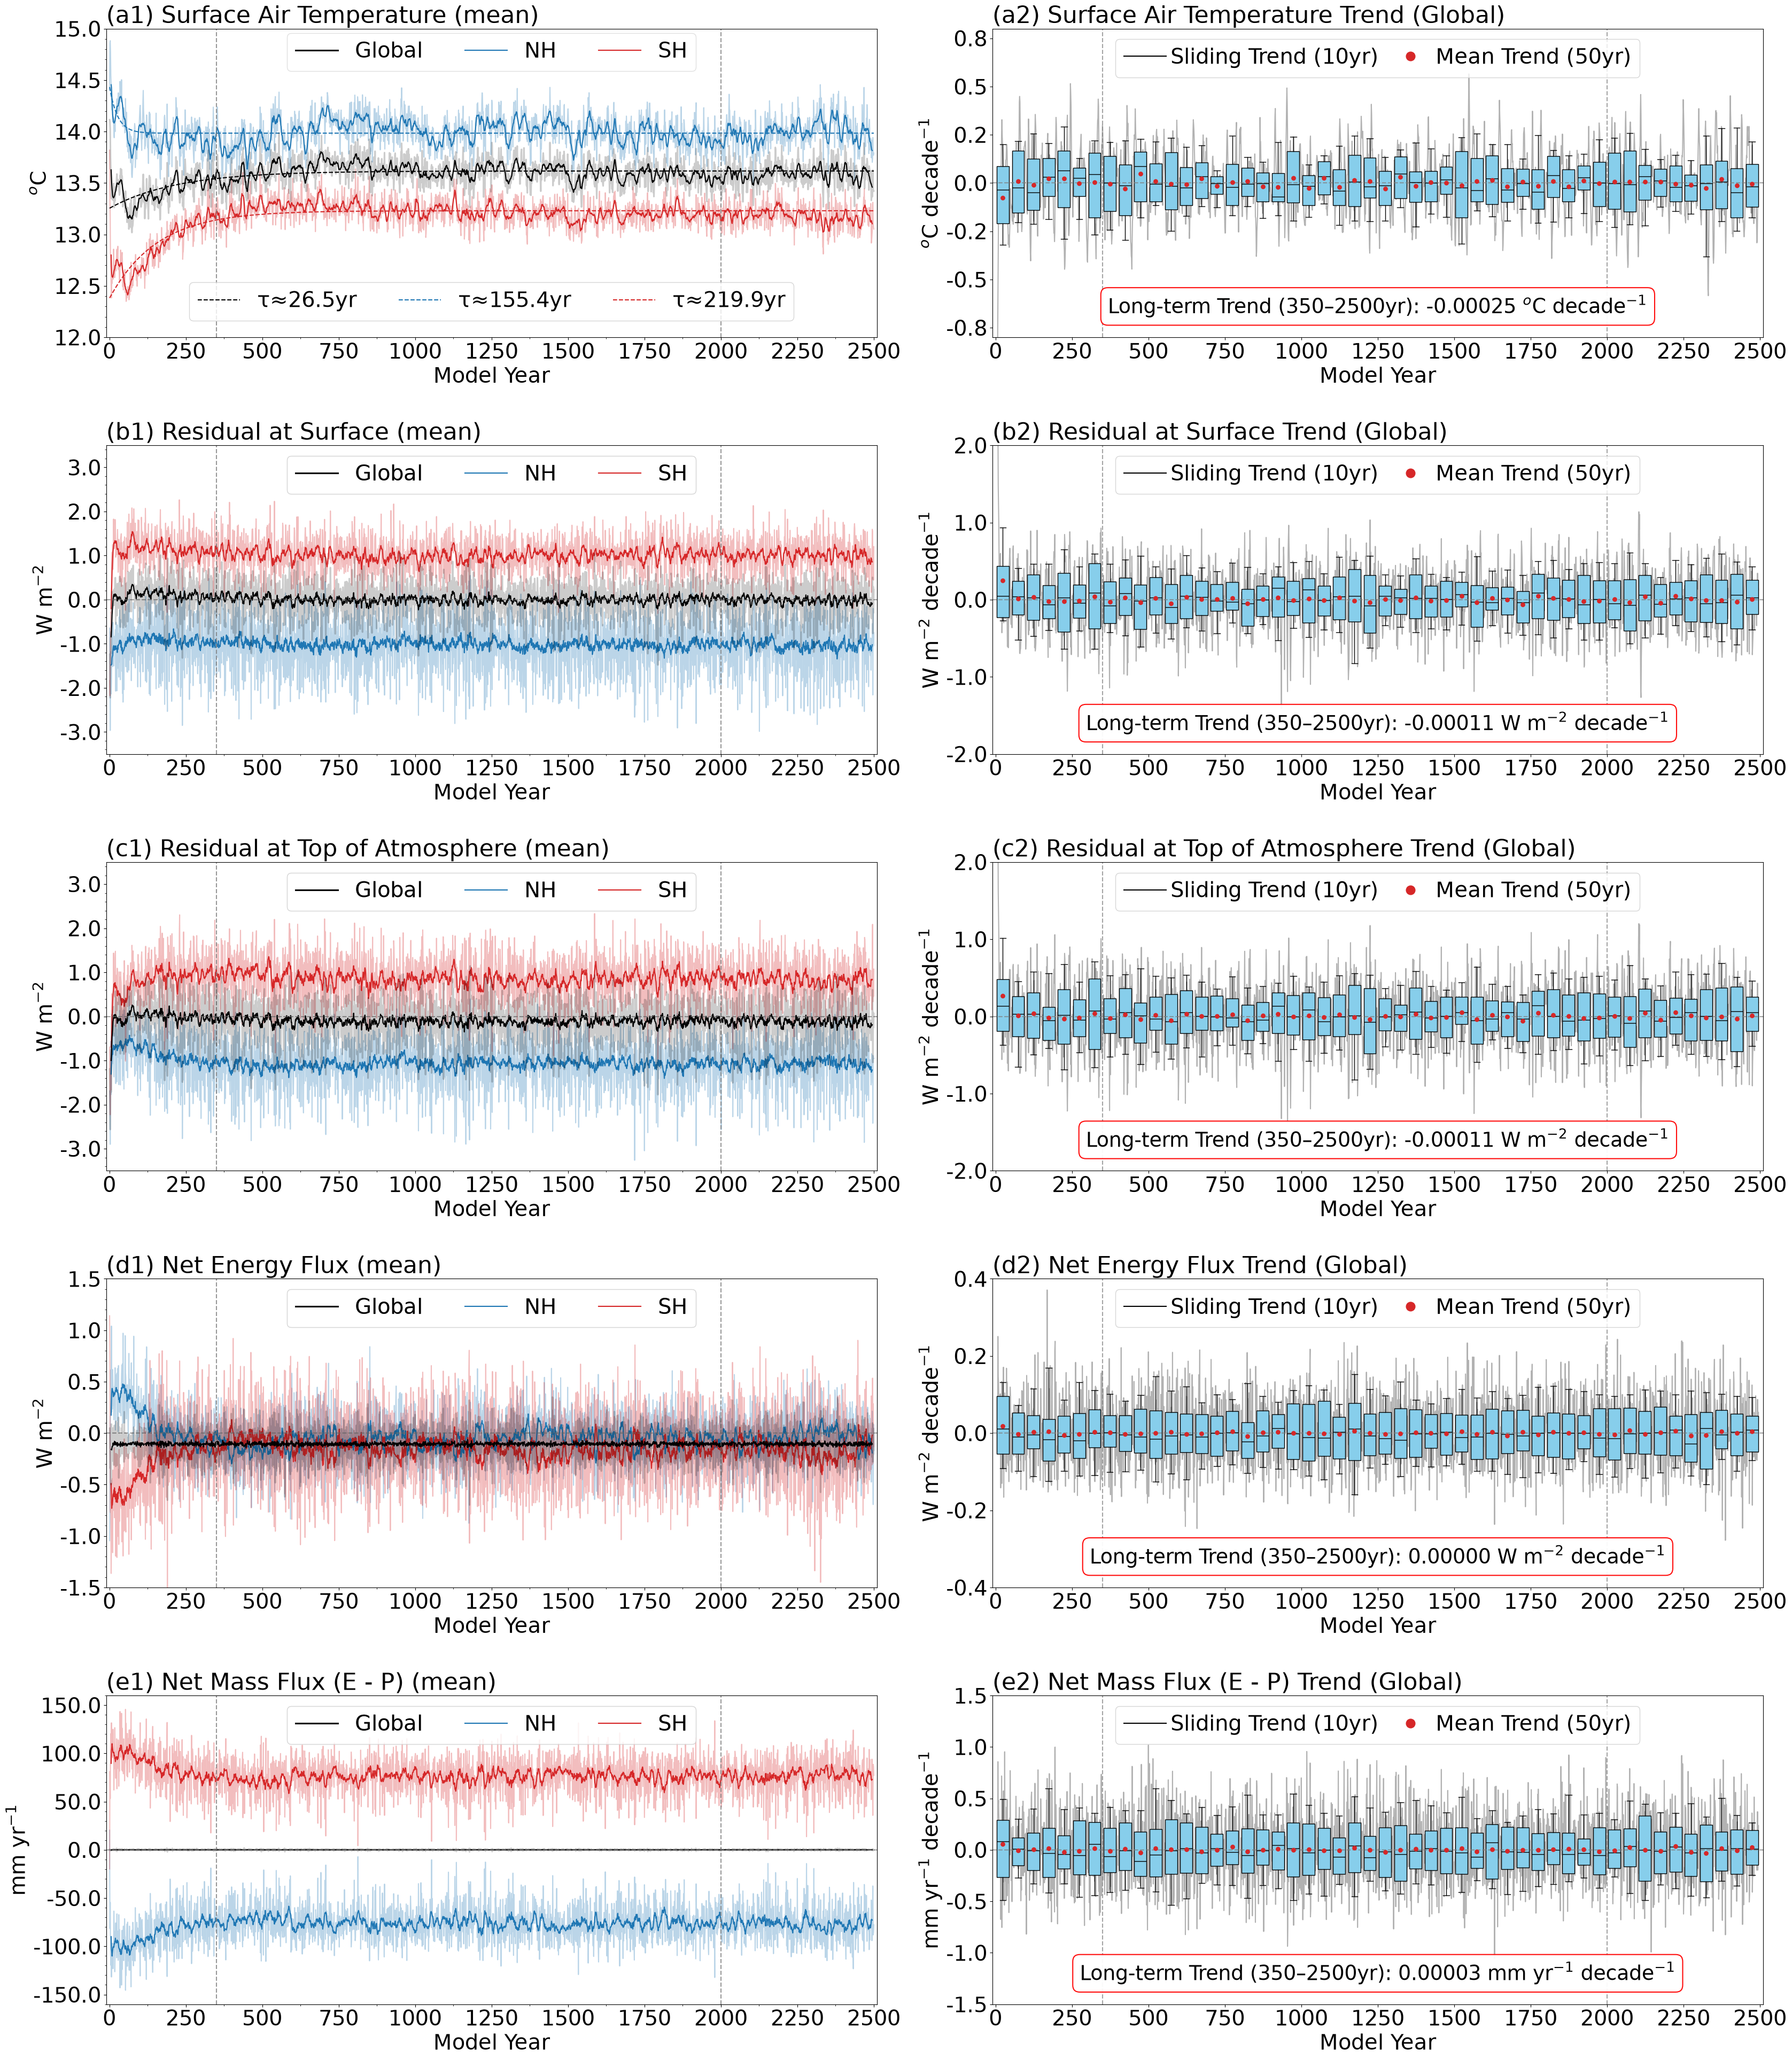

[INFO] All plots generated successfully.
web: https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/atm_flux


In [6]:
# === Time Series & Global Trend Panel ===
plotter = AtmosphereBalancePlotter(combined_tidy=combined_tidy)
fig_name = os.path.join(fig_dir, f"{experiment}_atm_trend_summary_global.pdf")

plotter.plot_time_series_panels(
    varnames=varnames,
    fig_name=fig_name,
    region_labels=region_labels,
    spinup_period=spinup_period,
    window=window,
    box_window=box_window,
    filter_window=filter_window,
    init_window=init_window,
    text_position_dict=text_position_dict,
    nxlab=nxlab,
    plot_dict=plot_dict,
    show_filter=show_filter, 
    show_decay=show_decay,
    decay_fit_range=decay_fit_range,
    decay_tail_years=decay_tail_years,
    use_filtered_for_fit=use_filtered_for_fit,
    syear=plot_syear,
    eyear=plot_eyear,
    fig_id=fig_id,
    fontz=fontz,
    figsize=figsize,
    show_trend_range_box=show_trend_range_box,
    trend_mode=trend_mode,
    trend_fit_range=trend_fit_range,
    use_filtered_for_trend=use_filtered_for_trend,
    show_mean_box=show_mean_box, 
    vars_for_mean_box=vars_for_mean_box
)

print("[INFO] All plots generated successfully.")

publish(FIG_DIR, DATA_DIR)
print("web:", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))


## 2.2 Trend summary, hemispheres
### Settings

In [7]:
data_dir    = MODEL_ROOT
data_dir    = DATA_DIR
fig_dir     = FIG_DIR #os.path.join(results_dir, "figures")
os.makedirs(fig_dir, exist_ok=True)

# === Select experiment ===
experiment = EXPERIMENT
season = "annual" # or monthly
spinup_period = list(SPINUP_MARKERS)
plot_syear = CTRL_YEARS[0]
plot_eyear = CTRL_YEARS[1]

if 'run_dict' not in globals():
    raise RuntimeError("[ERROR] 'run_dict' is not defined. Please define it before running.")

if experiment not in run_dict:
    raise ValueError(f"[ERROR] '{experiment}' not found in run_dict.")

combined_tidy = os.path.join(
    data_dir, f"{experiment}_energy_timeseries_{season}.nc"
)

if not os.path.isfile(combined_tidy):
    raise FileNotFoundError(f"Missing tidy file: {combined_tidy}")

# === Region labels ===
region_labels = {
    0: "Global",
    1: "Northern Hemisphere",
    2: "Southern Hemisphere"
}

# === Plot variables ===
var_dict = {
    #"global_surface_skin_temperature": {
    #    "name": "TS",       'label': "TS",      'unit': '$^{o}$C'
    #},
    #"net_toa_flux_restom":            {
    #    "name": "RESTOM",   'label': "RESTOM",  'unit': r'W m$^{-2}$'
    #},
    "TAS": {
        "name": "TAS", 
        'label': "Surface Air Temperature",  
        'unit': r'$^{o}$C',
        "decay" : True,
        "min"   : 12.0,
        "max"   : 15.0,
        "dmin"  : -0.8,
        "dmax"  : 0.8,
    },
    "RESSURF": {
        "name": "RESSURF", 
        'label': "Residual at Surface",  
        'unit': r'W m$^{-2}$',
        "decay" : False,
        "min"   : -3.5,
        "max"   : 3.5,
        "dmin"  : -2.0,
        "dmax"  : 2.0,
    },
    "RESTOA": {
        "name": "RESTOA",   
        'label': "Residual at Top of Atmosphere",  
        'unit': r'W m$^{-2}$',
        "decay" : False,
        "min"   : -3.5,
        "max"   : 3.5,
        "dmin"  : -2.0,
        "dmax"  :  2.0,
    },
    "RESNET": {
        "name": "RESNET",   
        'label': "Net Energy Flux",  
        'unit': r'W m$^{-2}$',
        "decay" : False,
        "min"   : -1.5,
        "max"   : 1.5,
        "dmin"  : -1.0,
        "dmax"  :  1.0,
    },
    "MASSFLUX": {
        "name": "MASSFLUX", 
        'label': "Net Mass Flux (E - P)",   
        'unit': r'mm yr$^{-1}$',
        "decay" : False,
        "min"   : -160.0,
        "max"   :  160.0,
        "dmin"  : -60,
        "dmax"  :  60,
    },
}

window = 10
box_window = 50
filter_window = 11
init_window = 0
nxlab = 250
force_process = False # Flase if file already processed
xr_engine = "netcdf4"
xr_chunks = None 

show_decay = True 
show_filter = True 
decay_fit_range=(plot_syear, spinup_period[1])     # e.g., (0, 350) or (0, spinup_markers[0])
decay_tail_years=200

use_filtered_for_fit=True
figsize = (40,48)
fontz = 30
nrows = 1
ncols = 2
fig_id = 0

# Create default positions for all short names
show_trend_range_box = True 
trend_mode = "full_period"
trend_fit_range = (spinup_period[0],plot_eyear)        # e.g., (syear, eyear) or (spinup_markers[0], eyear)
use_filtered_for_trend = True  # use yf if available

text_position_dict = {
    meta['name']: {'x': 0.02, 'y': 0.98}
    for meta in var_dict.values()
}
# Override specific variables with custom positions
text_position_dict.update({
    'TAS':      {'x': 0.50, 'y': 0.10},
    'RESSURF':  {'x': 0.50, 'y': 0.10},
    'RESTOA':   {'x': 0.50, 'y': 0.10},
    'RESNET':   {'x': 0.50, 'y': 0.10},
    'MASSFLUX': {'x': 0.50, 'y': 0.10}
}) 

# === Summary grid ===
varnames   = [meta["name"] for meta in var_dict.values()]
plot_dict = {
    meta["name"]: {
        "label": meta["label"],
        "unit": meta["unit"],
        "decay": meta.get("decay", False),
        "min": meta.get("min", None),
        "max": meta.get("max", None),
        "dmin": meta.get("dmin", None),
        "dmax": meta.get("dmax", None),
        "decay": meta.get("decay", False),
    }
    for meta in var_dict.values()
}

color_dict = {
    'black': '#000000', 'blue': '#1f77b4', 'red': '#d62728',
    'skyblue': '#87ceeb', 'gray': '#7f7f7f'
}


### Compute & plot

/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/coupled_spinup_evaluation/util/ctrl_plotting.py:1053: UserWarning: Unit missing for 'RESSURF' [region=Global]. Expected 'None'. Data will be used as-is; set df.attrs['units']['RESSURF'] to silence.
  self._check_and_warn_units(varname, units_map, y=y, where=f"region={name}")
/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/coupled_spinup_evaluation/util/ctrl_plotting.py:1053: UserWarning: Unit missing for 'RESSURF' [region=Northern Hemisphere]. Expected 'None'. Data will be used as-is; set df.attrs['units']['RESSURF'] to silence.
  self._check_and_warn_units(varname, units_map, y=y, where=f"region={name}")
/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/coupled_spinup_evaluation/util/ctrl_plotting.py:1053: UserWarning: Unit missing for 'RESSURF' [region=Southern Hemisphere]. Expected 'None'. Data will be used as-is; set df.attrs['units']['RESSURF'] to silence.
  self._check_and

[PLOT] Saved: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/atm_flux/Full-CPL_atm_trend_summary_hemisphere.pdf


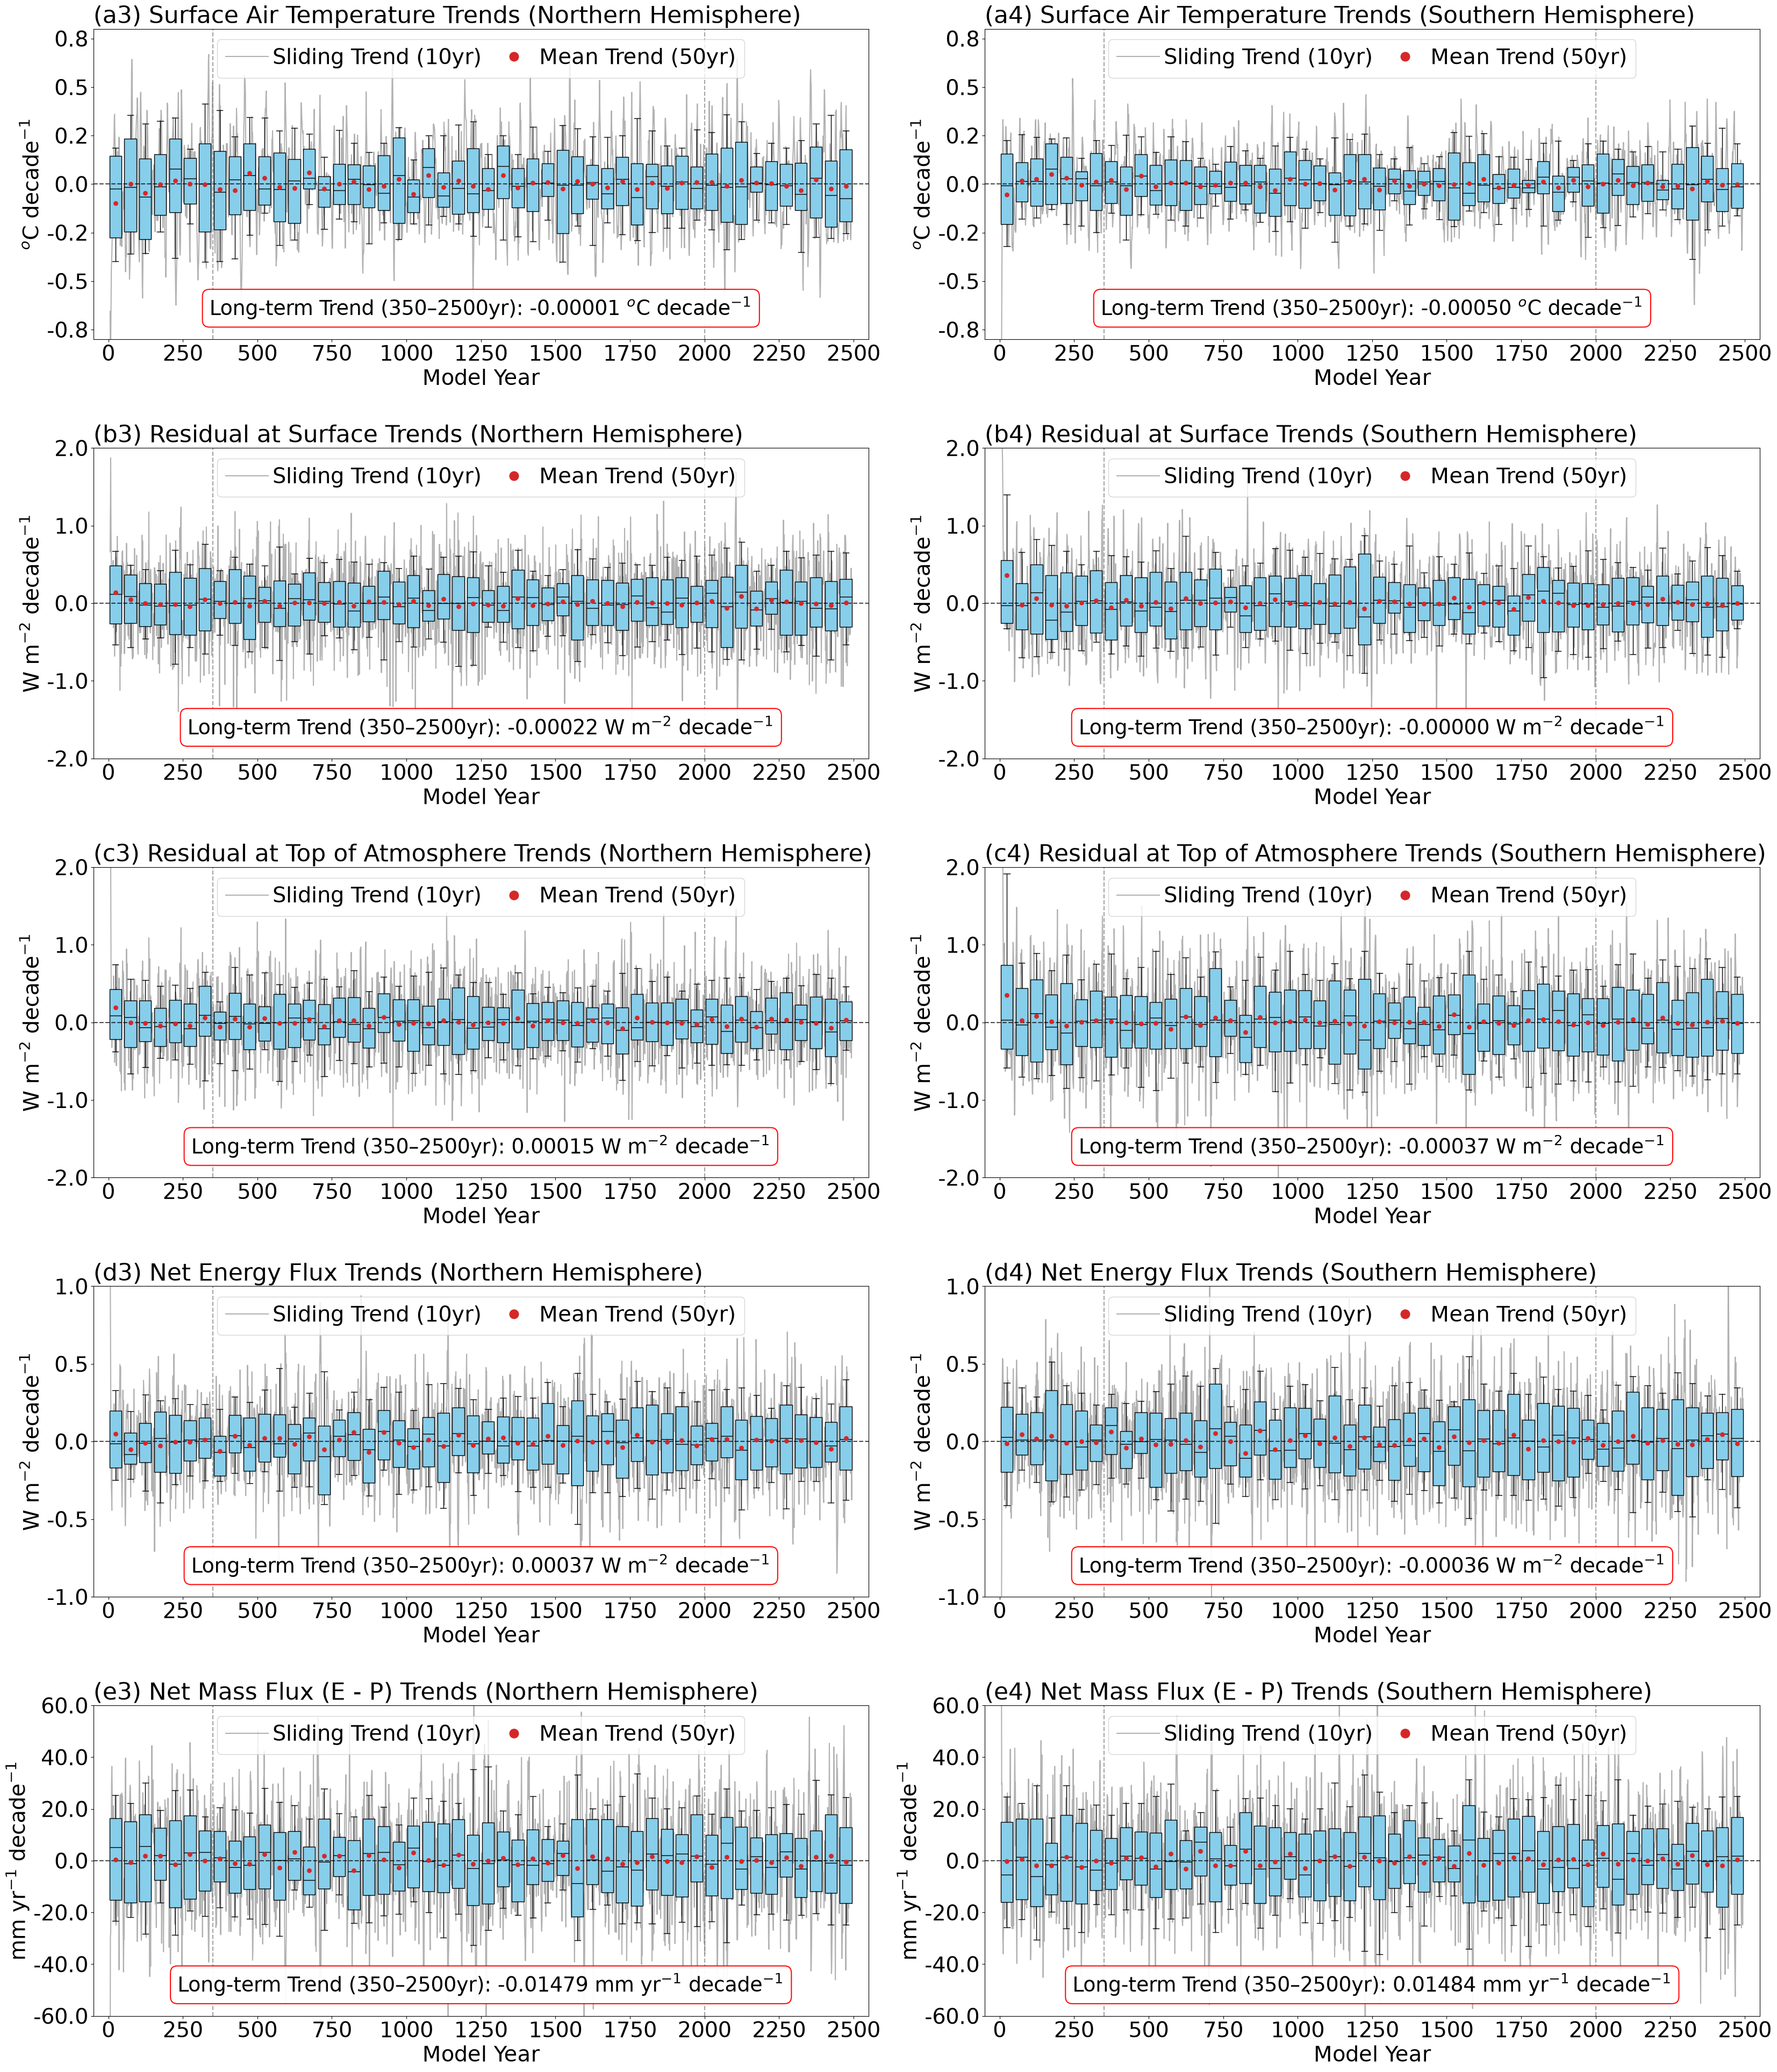

[INFO] All plots generated successfully.
web: https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/atm_flux


In [8]:
# === Time Series & Global Trend Panel ===
plotter = AtmosphereBalancePlotter(combined_tidy=combined_tidy)
fig_name = os.path.join(fig_dir, f"{experiment}_atm_trend_summary_hemisphere.pdf")

plotter.plot_hemisphere_panels(
    varnames=varnames,
    fig_name=fig_name,
    region_labels=region_labels,
    spinup_period=spinup_period,
    window=window,
    box_window=box_window,
    filter_window=filter_window,
    init_window=init_window,
    text_position_dict=text_position_dict,
    nxlab=nxlab,
    plot_dict=plot_dict,
    show_filter=show_filter, 
    show_decay=show_decay,
    decay_fit_range=decay_fit_range,
    decay_tail_years=decay_tail_years,
    use_filtered_for_fit=use_filtered_for_fit,
    syear=plot_syear,
    eyear=plot_eyear,
    fig_id=fig_id,
    fontz=fontz,
    figsize=figsize,
    show_trend_range_box=show_trend_range_box,
    trend_mode=trend_mode,
    trend_fit_range=trend_fit_range,
    use_filtered_for_trend=use_filtered_for_trend,
)

print("[INFO] All plots generated successfully.")

publish(FIG_DIR, DATA_DIR)
print("web:", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))
